In [1]:
from sklearn import datasets
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [3]:
iris = datasets.load_iris()

In [4]:
X = iris.data
y = iris.target

In [5]:
X_std = StandardScaler().fit_transform(X)
X_mm = MinMaxScaler().fit_transform(X)

In [6]:
kmeans_raw = KMeans(n_clusters=3, random_state=0).fit(X)
kmeans_std = KMeans(n_clusters=3, random_state=0).fit(X_std)
kmeans_mm = KMeans(n_clusters=3, random_state=0).fit(X_mm)
print(f"Silhouette raw={silhouette_score(X, kmeans_raw.labels_):.3f}, std={silhouette_score(X_std, kmeans_std.labels_):.3f}, minmax={silhouette_score(X_mm, kmeans_mm.labels_):.3f}")

Silhouette raw=0.553, std=0.460, minmax=0.505


Silhouette raw=0.553, std=0.460, minmax=0.505


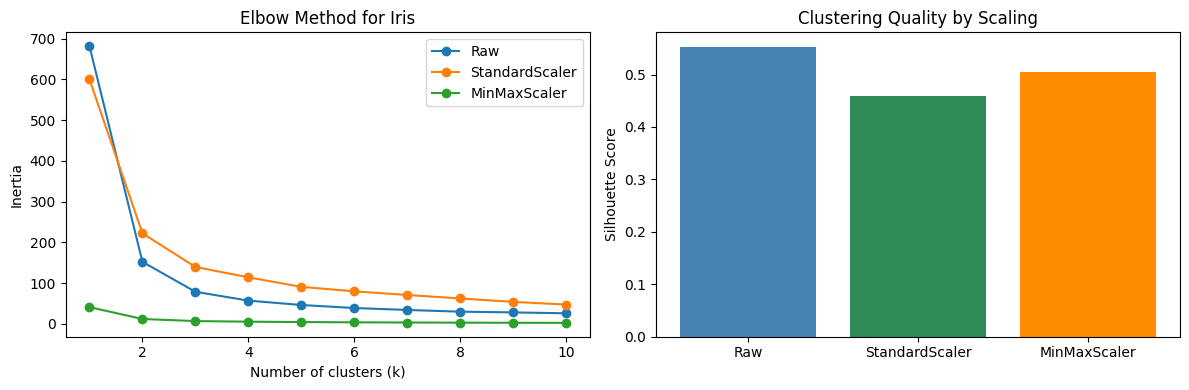

In [7]:
print(f"Silhouette raw={silhouette_score(X, kmeans_raw.labels_):.3f}, std={silhouette_score(X_std, kmeans_std.labels_):.3f}, minmax={silhouette_score(X_mm, kmeans_mm.labels_):.3f}")
inertia_raw = [KMeans(n_clusters=i, random_state=0).fit(X).inertia_ for i in range(1, 11)]
inertia_std = [KMeans(n_clusters=i, random_state=0).fit(X_std).inertia_ for i in range(1, 11)]
inertia_mm = [KMeans(n_clusters=i, random_state=0).fit(X_mm).inertia_ for i in range(1, 11)]
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), inertia_raw, 'o-', label='Raw')
plt.plot(range(1, 11), inertia_std, 'o-', label='StandardScaler')
plt.plot(range(1, 11), inertia_mm, 'o-', label='MinMaxScaler')

plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Iris')
plt.legend()
plt.subplot(1, 2, 2)
plt.bar(['Raw','StandardScaler','MinMaxScaler'], [silhouette_score(X, kmeans_raw.labels_), silhouette_score(X_std, kmeans_std.labels_), silhouette_score(X_mm, kmeans_mm.labels_)], color=['steelblue','seagreen','darkorange'])
plt.ylabel('Silhouette Score')
plt.title('Clustering Quality by Scaling')
plt.tight_layout()
plt.show()

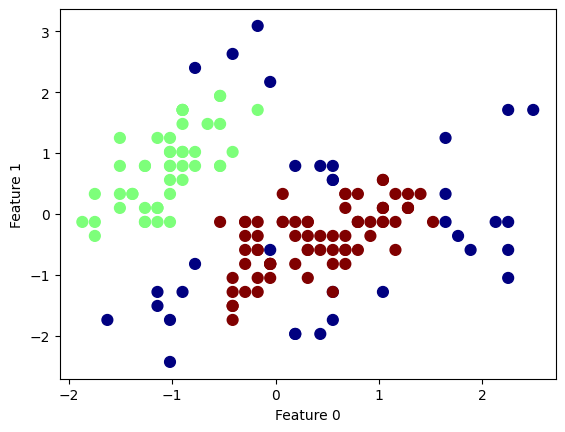

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
import plottinglib as plotlib
#X, y = make_moons(n_samples=200, noise=0.05, random_state=0)

# rescale the data to zero mean and unit variance
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

dbscan = DBSCAN()
clusters = dbscan.fit_predict(X_scaled)

# plot the cluster assignments
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='jet', s=60)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

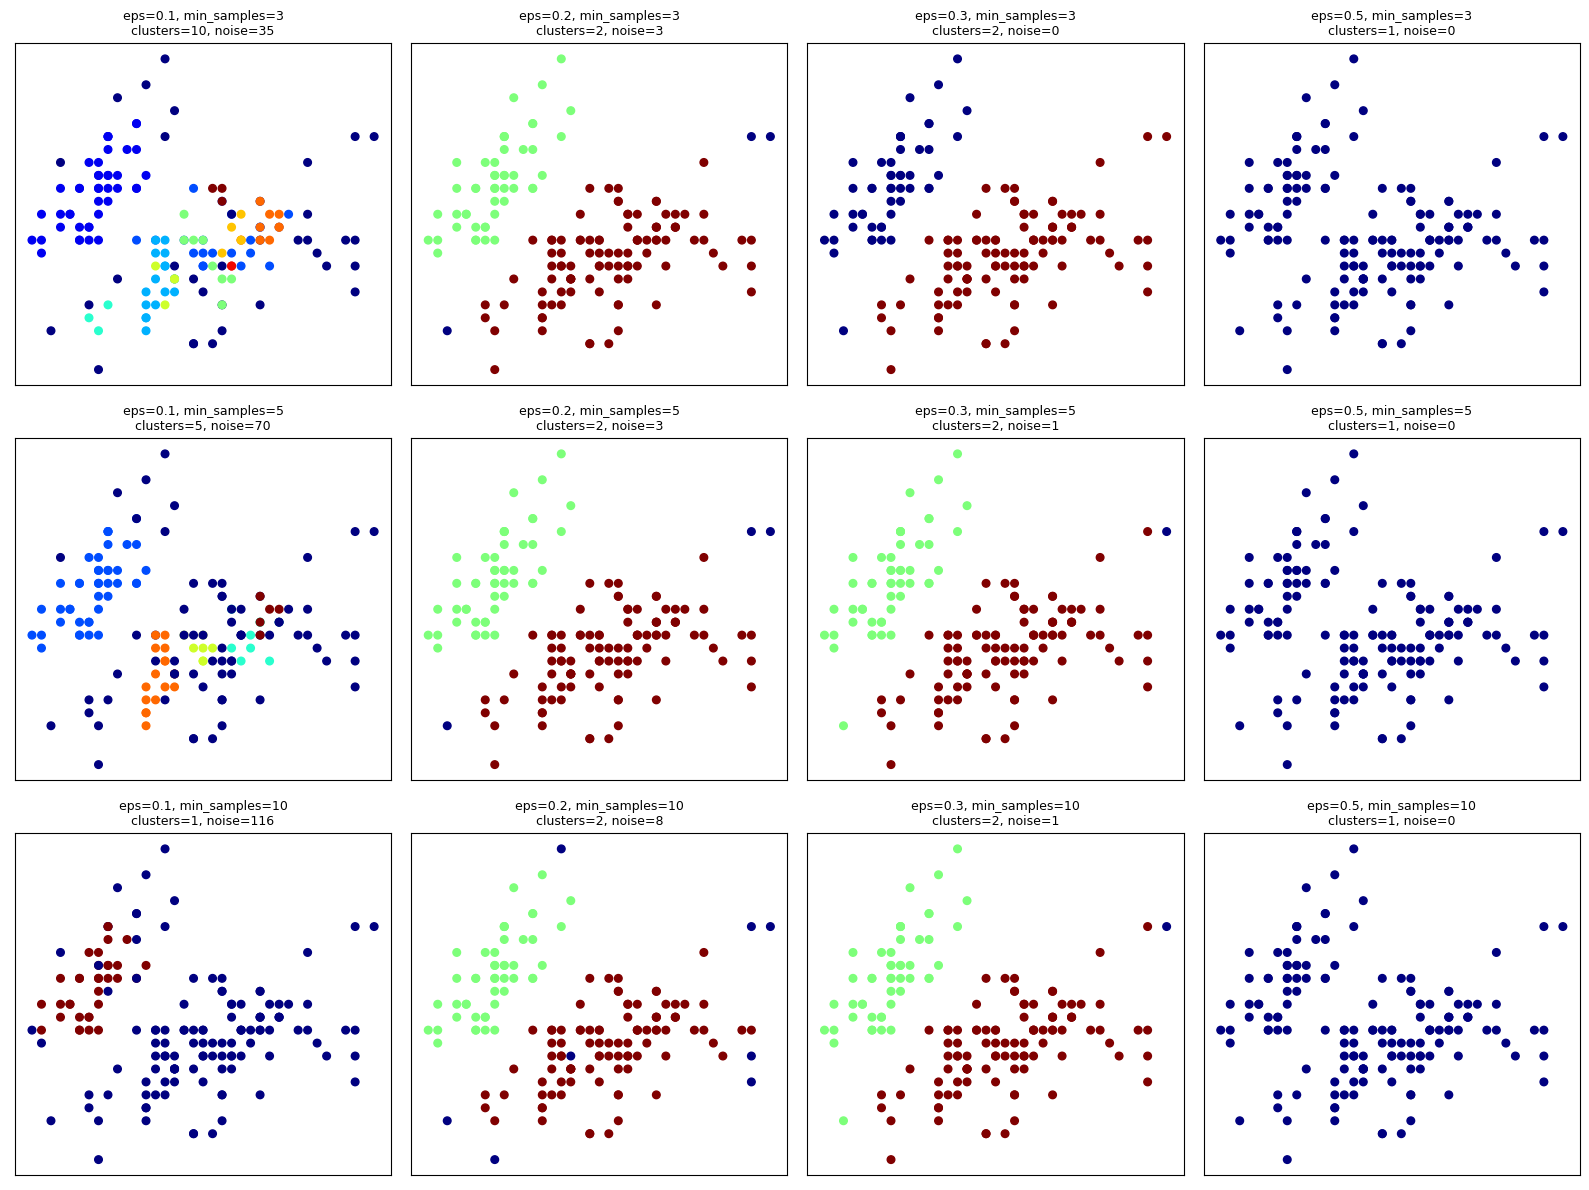

In [9]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs

# generate or load your data
#X, y = make_blobs(n_samples=300, random_state=0)

# rescale the data to [0, 1]
scaler_mm = MinMaxScaler()
X_scaled = scaler_mm.fit_transform(X)

# define the parameter combinations you want to try
eps_values = [0.1, 0.2, 0.3, 0.5]
min_samples_values = [3, 5, 10]

n_rows = len(min_samples_values)
n_cols = len(eps_values)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

for i, min_samples in enumerate(min_samples_values):
    for j, eps in enumerate(eps_values):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
        n_noise = list(clusters).count(-1)

        ax = axes[i, j]
        ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='jet', s=30)
        ax.set_title(f"eps={eps}, min_samples={min_samples}\n"
                     f"clusters={n_clusters}, noise={n_noise}", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()


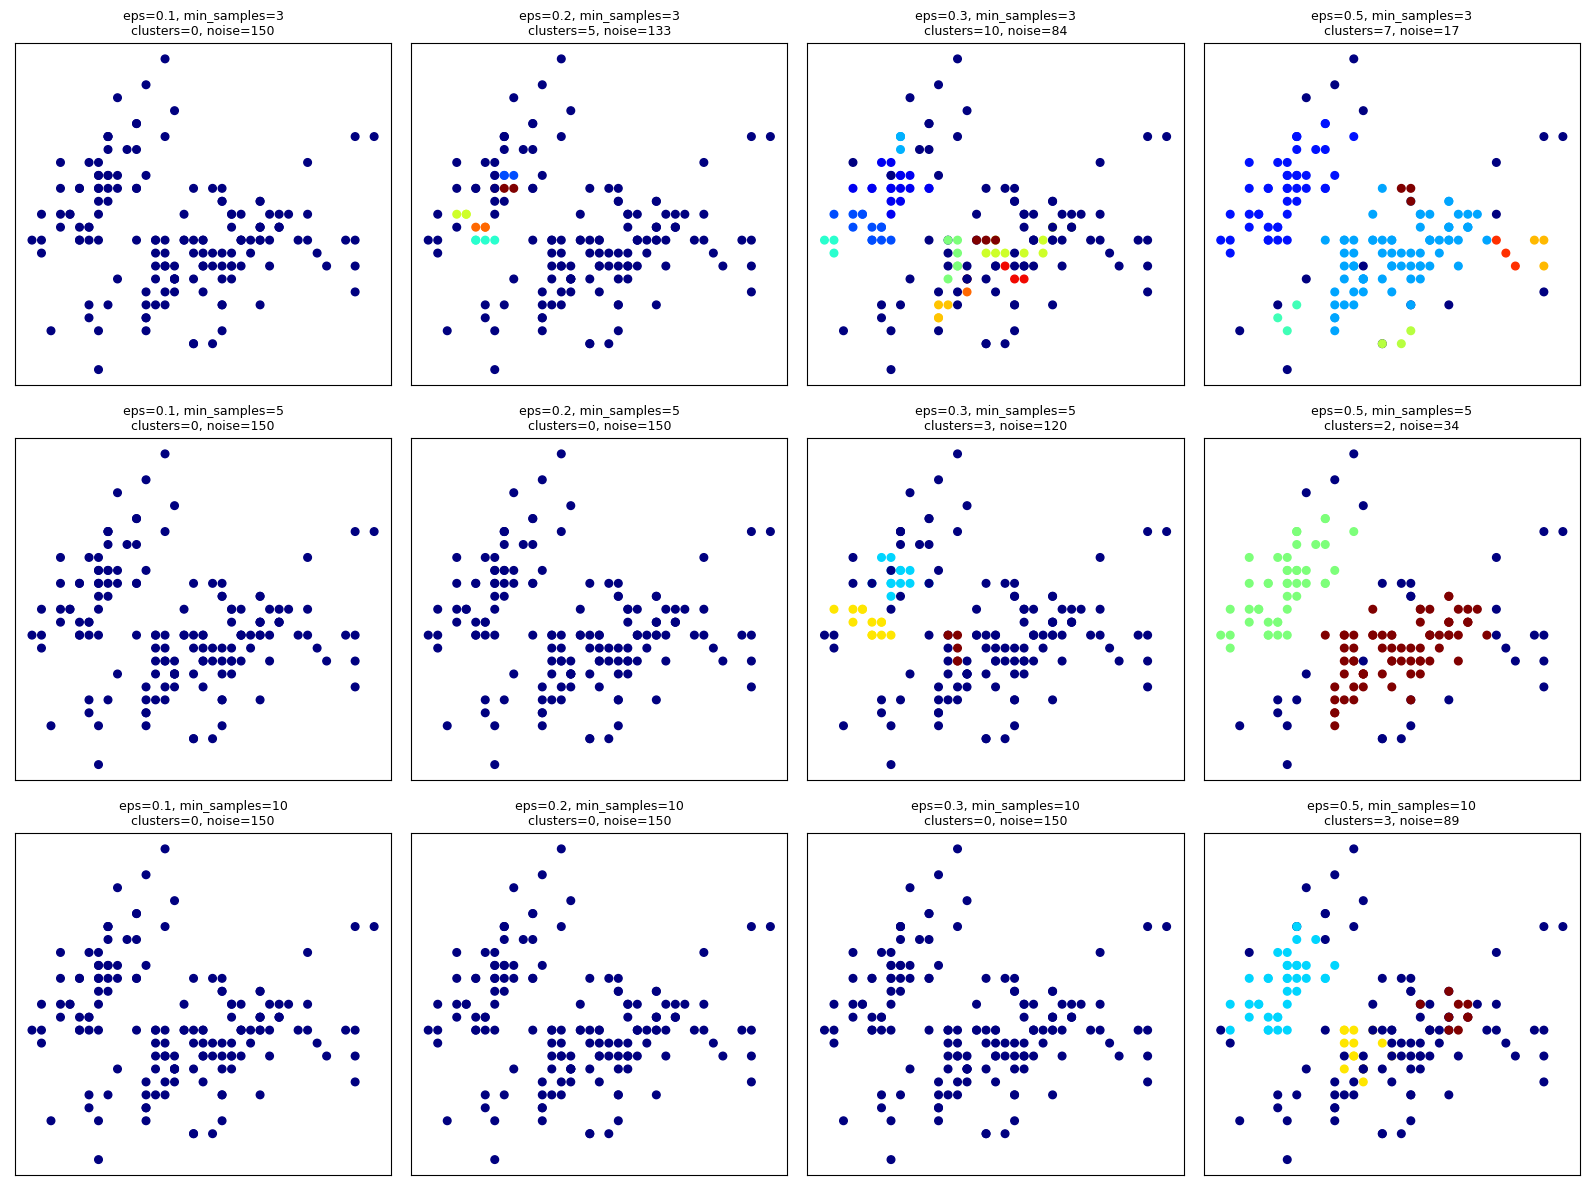

In [10]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs

# generate or load your data
#X, y = make_blobs(n_samples=300, random_state=0)

# rescale the data to [0, 1]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# define the parameter combinations you want to try
eps_values = [0.1, 0.2, 0.3, 0.5]
min_samples_values = [3, 5, 10]

n_rows = len(min_samples_values)
n_cols = len(eps_values)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

for i, min_samples in enumerate(min_samples_values):
    for j, eps in enumerate(eps_values):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
        n_noise = list(clusters).count(-1)

        ax = axes[i, j]
        ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='jet', s=30)
        ax.set_title(f"eps={eps}, min_samples={min_samples}\n"
                     f"clusters={n_clusters}, noise={n_noise}", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()


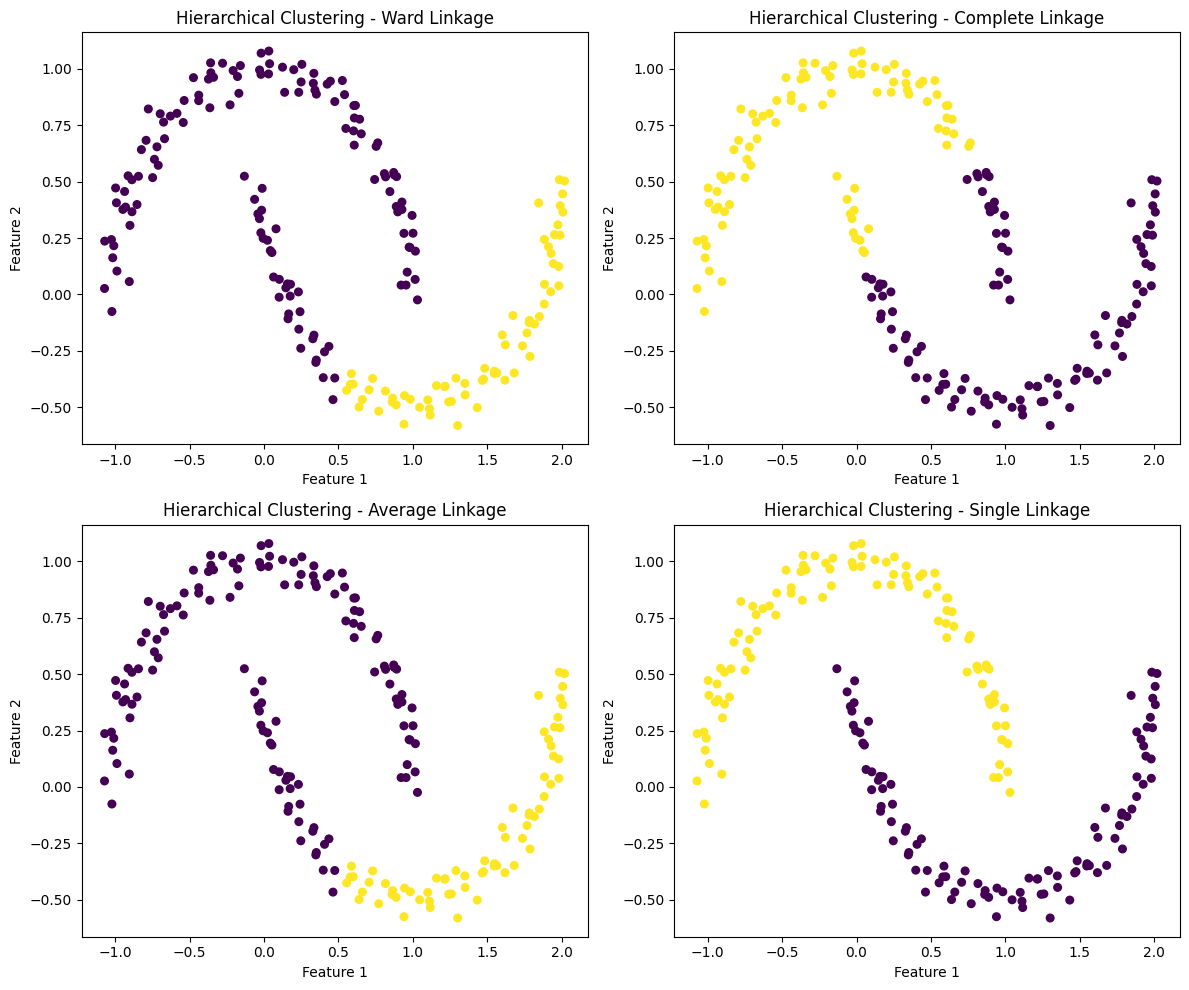

In [11]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import AgglomerativeClustering

# Generate the dataset
X, y = make_moons(
    n_samples=200,
    noise=0.05,
    random_state=0
)

# Define linkage methods
linkages = ["ward", "complete", "average", "single"]

# Create a figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

# Perform hierarchical clustering for each linkage method
for ax, linkage in zip(axes, linkages):

    # Ward linkage only supports Euclidean distance
    clustering = AgglomerativeClustering(
        n_clusters=2,
        linkage=linkage
    )

    labels = clustering.fit_predict(X)

    # Plot clustering result
    ax.scatter(
        X[:, 0],
        X[:, 1],
        c=labels,
        cmap="viridis",
        s=30
    )

    ax.set_title(f"Hierarchical Clustering - {linkage.capitalize()} Linkage")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()